In [ ]:
!pip install numpy pandas matplotlib scikit-learn opencv-python

In [ ]:
import numpy as np
import os
import cv2
# Unzip the dataset
!unzip -q /content/brain_tumor_dataset.zip -d /content/data
data = []
labels = []
categories = ["yes", "no"]
for category in categories:
    path = "/content/data/brain_tumor_dataset/" + category
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        if image is None:
            continue
        # grayscale reduces noise
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # smaller size reduces overfitting
        image = cv2.resize(image, (64,64))
        data.append(image)
        if category == "yes":
            labels.append(1)
        else:
            labels.append(0)

X = np.array(data)
y = np.array(labels)
# normalization
X = X / 255.0
# flatten image
X = X.reshape(len(X), -1)
print("Dataset Shape:", X.shape)

replace /content/data/brain_tumor_dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset Shape: (253, 4096)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Logistic Regression (L2 regularization)
lr = LogisticRegression(
    C=0.3,
    max_iter=2000
)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
# KNN (higher k reduces overfitting)
knn = KNeighborsClassifier(
    n_neighbors=11
)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)

# Decision Tree (regularization applied)
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=25,
    min_samples_leaf=10
)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

# SVM (strong regularization)
svm = SVC(
    kernel='rbf',
    C=0.7,
    gamma='scale',
    probability=True
)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)

# Random Forest (regularized)
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

# AdaBoost (reduced complexity)
adb = AdaBoostClassifier(
    n_estimators=80,
    learning_rate=0.3
)
adb.fit(X_train, y_train)
pred_adb = adb.predict(X_test)
acc_adb = accuracy_score(y_test, pred_adb)
# accuracy table
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy":[
        acc_lr,
        acc_knn,
        acc_dt,
        acc_svm,
        acc_rf,
        acc_adb
    ]
})
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
0  Logistic Regression  0.843137
3                  SVM  0.784314
1                  KNN  0.764706
4        Random Forest  0.745098
2        Decision Tree  0.725490
5             AdaBoost  0.725490


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
def specificity(cm):
    TN = cm[0][0]
    FP = cm[0][1]
    return TN/(TN+FP)
metrics_table = pd.DataFrame({
"Model":[
"Logistic Regression",
"KNN",
"Decision Tree",
"SVM",
"Random Forest",
"AdaBoost"
],

"Accuracy":[
acc_lr,
acc_knn,
acc_dt,
acc_svm,
acc_rf,
acc_adb
],

"Precision":[
precision_score(y_test,pred_lr),
precision_score(y_test,pred_knn),
precision_score(y_test,pred_dt),
precision_score(y_test,pred_svm),
precision_score(y_test,pred_rf),
precision_score(y_test,pred_adb)
],

"Recall":[
recall_score(y_test,pred_lr),
recall_score(y_test,pred_knn),
recall_score(y_test,pred_dt),
recall_score(y_test,pred_svm),
recall_score(y_test,pred_rf),
recall_score(y_test,pred_adb)
],

"Specificity":[
specificity(confusion_matrix(y_test,pred_lr)),
specificity(confusion_matrix(y_test,pred_knn)),
specificity(confusion_matrix(y_test,pred_dt)),
specificity(confusion_matrix(y_test,pred_svm)),
specificity(confusion_matrix(y_test,pred_rf)),
specificity(confusion_matrix(y_test,pred_adb))
],

"F1 Score":[
f1_score(y_test,pred_lr),
f1_score(y_test,pred_knn),
f1_score(y_test,pred_dt),
f1_score(y_test,pred_svm),
f1_score(y_test,pred_rf),
f1_score(y_test,pred_adb)
],

"AUC":[
roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]),
roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]),
roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
roc_auc_score(y_test, adb.predict_proba(X_test)[:,1])
]
})
print(metrics_table.round(3).to_string(index=False))

              Model  Accuracy  Precision  Recall  Specificity  F1 Score   AUC
Logistic Regression     0.843      0.848   0.903         0.75     0.875 0.887
                KNN     0.765      0.757   0.903         0.55     0.824 0.791
      Decision Tree     0.725      0.793   0.742         0.70     0.767 0.736
                SVM     0.784      0.750   0.968         0.50     0.845 0.871
      Random Forest     0.745      0.725   0.935         0.45     0.817 0.848
           AdaBoost     0.725      0.718   0.903         0.45     0.800 0.774


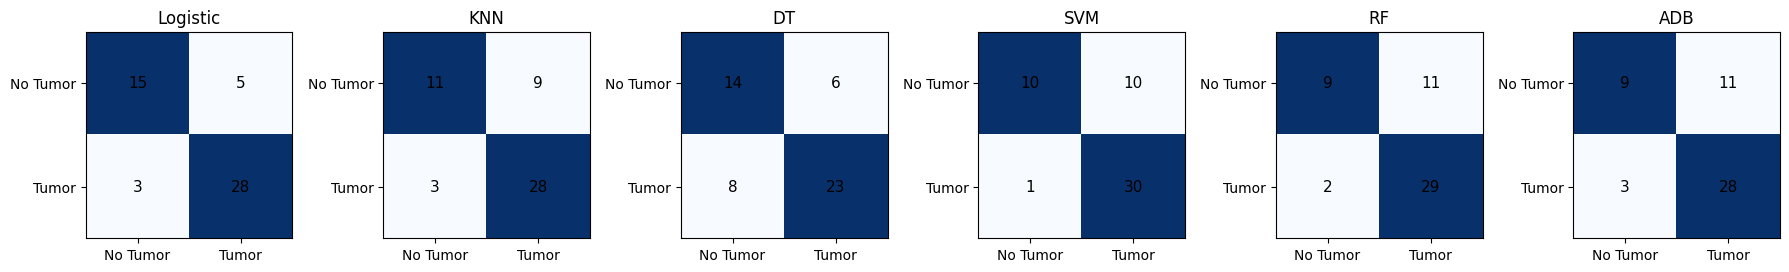

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
# confusion matrices
cm_lr = confusion_matrix(y_test, pred_lr)
cm_knn = confusion_matrix(y_test, pred_knn)
cm_dt = confusion_matrix(y_test, pred_dt)
cm_svm = confusion_matrix(y_test, pred_svm)
cm_rf = confusion_matrix(y_test, pred_rf)
cm_adb = confusion_matrix(y_test, pred_adb)
cms = [
    ("Logistic", cm_lr),
    ("KNN", cm_knn),
    ("DT", cm_dt),
    ("SVM", cm_svm),
    ("RF", cm_rf),
    ("ADB", cm_adb)
]
fig, axes = plt.subplots(1, 6, figsize=(18,3))
for ax, (name, cm) in zip(axes, cms):
    # create color matrix
    color_matrix = np.zeros_like(cm)
    # diagonal blue (value 1
    np.fill_diagonal(color_matrix, 1)
    ax.imshow(color_matrix, cmap="Blues", vmin=0, vmax=1)
    # show numbers
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j],
                    ha="center",
                    va="center",
                    fontsize=11,
                    color="black" )

    ax.set_title(name)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["No Tumor","Tumor"])
    ax.set_yticklabels(["No Tumor","Tumor"])
plt.tight_layout()
plt.show()

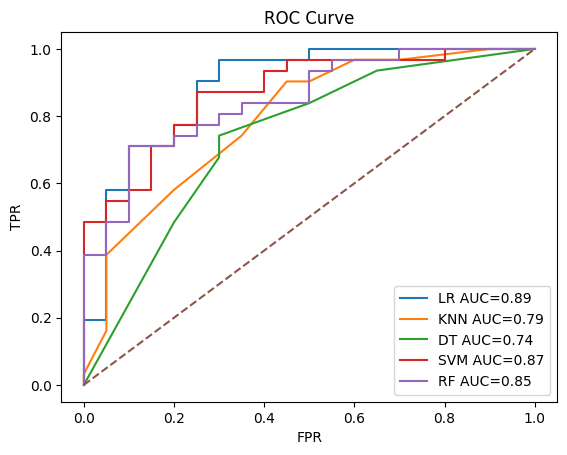

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# function to get ROC values
def get_roc(model):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc


# get ROC for each model
fpr_lr, tpr_lr, auc_lr = get_roc(lr)
fpr_knn, tpr_knn, auc_knn = get_roc(knn)
fpr_dt, tpr_dt, auc_dt = get_roc(dt)
fpr_svm, tpr_svm, auc_svm = get_roc(svm)
fpr_rf, tpr_rf, auc_rf = get_roc(rf)


# plot
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"LR AUC={auc_lr:.2f}")
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC={auc_knn:.2f}")
plt.plot(fpr_dt, tpr_dt, label=f"DT AUC={auc_dt:.2f}")
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC={auc_svm:.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC={auc_rf:.2f}")

# diagonal line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_table = pd.DataFrame({

"Model":[
"Logistic Regression",
"KNN",
"Decision Tree",
"SVM",
"Random Forest",
"AdaBoost"
],

"CV Accuracy":[

cross_val_score(lr,X,y,cv=5).mean(),

cross_val_score(knn,X,y,cv=5).mean(),

cross_val_score(dt,X,y,cv=5).mean(),

cross_val_score(svm,X,y,cv=5).mean(),

cross_val_score(rf,X,y,cv=5).mean(),

cross_val_score(adb,X,y,cv=5).mean()

]

})

print(cv_table.round(3).to_string(index=False))

              Model  CV Accuracy
Logistic Regression        0.810
                KNN        0.727
      Decision Tree        0.699
                SVM        0.790
      Random Forest        0.794
           AdaBoost        0.814


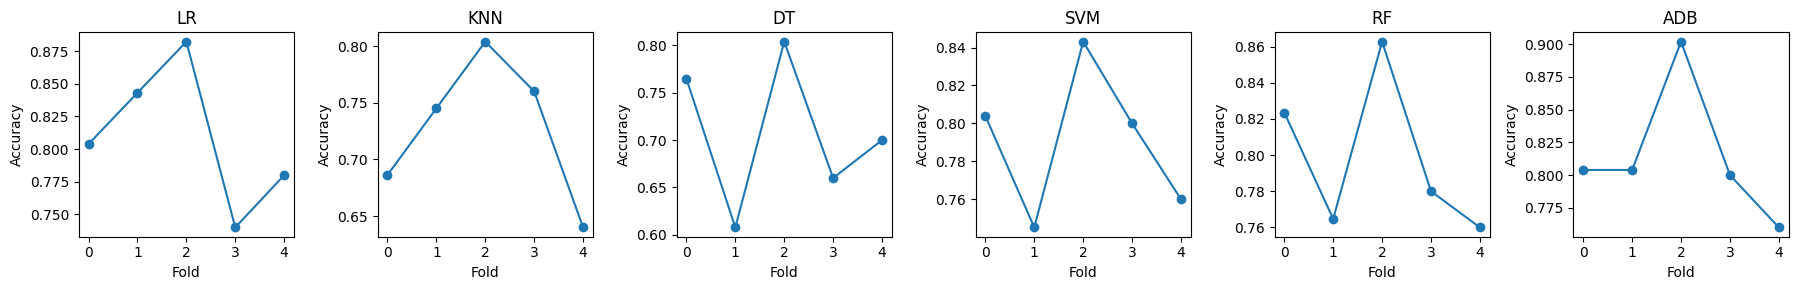

In [ ]:
import matplotlib.pyplot as plt

scores_lr = cross_val_score(lr,X,y,cv=5)

scores_knn = cross_val_score(knn,X,y,cv=5)

scores_dt = cross_val_score(dt,X,y,cv=5)

scores_svm = cross_val_score(svm,X,y,cv=5)

scores_rf = cross_val_score(rf,X,y,cv=5)

scores_adb = cross_val_score(adb,X,y,cv=5)


scores_all = [

("LR",scores_lr),

("KNN",scores_knn),

("DT",scores_dt),

("SVM",scores_svm),

("RF",scores_rf),

("ADB",scores_adb)

]


fig, axes = plt.subplots(1,6, figsize=(18,3))


for ax,(name,scores) in zip(axes,scores_all):

    ax.plot(scores, marker='o')

    ax.set_title(name)

    ax.set_xlabel("Fold")

    ax.set_ylabel("Accuracy")


plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd


# function to calculate train & test accuracy
def get_accuracy(model):

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)

    test_acc = accuracy_score(y_test, test_pred)

    return train_acc, test_acc


# calculate for each model
lr_train, lr_test = get_accuracy(lr)

knn_train, knn_test = get_accuracy(knn)

dt_train, dt_test = get_accuracy(dt)

svm_train, svm_test = get_accuracy(svm)

rf_train, rf_test = get_accuracy(rf)

adb_train, adb_test = get_accuracy(adb)


# create table
accuracy_table = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "AdaBoost"
    ],

    "Training Accuracy":[
        lr_train,
        knn_train,
        dt_train,
        svm_train,
        rf_train,
        adb_train
    ],

    "Testing Accuracy":[
        lr_test,
        knn_test,
        dt_test,
        svm_test,
        rf_test,
        adb_test
    ]

})


# clean display
accuracy_table = accuracy_table.round(3)

print("\nTraining vs Testing Accuracy:\n")

print(accuracy_table.to_string(index=False))


Training vs Testing Accuracy:

              Model  Training Accuracy  Testing Accuracy
Logistic Regression              1.000             0.843
                KNN              0.782             0.765
      Decision Tree              0.881             0.725
                SVM              0.916             0.784
      Random Forest              0.911             0.745
           AdaBoost              1.000             0.725


In [ ]:
print("Final Best Model: SVM")

print("Testing Accuracy:", svm_test)

print("Reason: best balance between bias and variance")

Final Best Model: SVM
Testing Accuracy: 0.7843137254901961
Reason: best balance between bias and variance
